## SLAM (Simultaneous Localization and Mapping) with `Husky` in MuJoCo

- 2D LiDAR simulation using MuJoCo rangefinder sensors (72 rays, 5-degree resolution)
- Maze environment generated from a grid map (inspired by PointMaze)
- Occupancy grid mapping with Bresenham ray casting
- Wall-following autonomous exploration

In [1]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import os, sys, tempfile
sys.path.append('../../')
from utils.mujoco_parser import MuJoCoParserClass
from utils.util import r2rpy
np.set_printoptions(precision=2, suppress=True, linewidth=100)
plt.rc('xtick', labelsize=6); plt.rc('ytick', labelsize=6)
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
print("MuJoCo version:[%s]" % (mujoco.__version__))

# Monkey-patch mujoco_viewer for MuJoCo 3.x compatibility
# (texid/texuniform/texrepeat were removed from MjvGeom)
import mujoco_viewer
_orig_add_marker_to_scene = mujoco_viewer.MujocoViewer._add_marker_to_scene
def _patched_add_marker_to_scene(self, marker):
    if self.scn.ngeom >= self.scn.maxgeom:
        return
    g = self.scn.geoms[self.scn.ngeom]
    g.dataid = -1
    g.objtype = mujoco.mjtObj.mjOBJ_UNKNOWN
    g.objid = -1
    g.category = mujoco.mjtCatBit.mjCAT_DECOR
    g.emission = 0
    g.specular = 0.5
    g.shininess = 0.5
    g.reflectance = 0
    g.type = mujoco.mjtGeom.mjGEOM_BOX
    g.size[:] = np.ones(3) * 0.1
    g.mat[:] = np.eye(3)
    g.rgba[:] = np.ones(4)
    for key, value in marker.items():
        if isinstance(value, (int, float, mujoco._enums.mjtGeom)):
            setattr(g, key, value)
        elif isinstance(value, (tuple, list, np.ndarray)):
            attr = getattr(g, key)
            attr[:] = np.asarray(value).flat[:len(attr)]
        elif isinstance(value, str):
            setattr(g, key, value)
    self.scn.ngeom += 1
mujoco_viewer.MujocoViewer._add_marker_to_scene = _patched_add_marker_to_scene
print("Patched mujoco_viewer for MuJoCo 3.x compatibility.")

MuJoCo version:[3.8.1]
Patched mujoco_viewer for MuJoCo 3.x compatibility.


### Define Maze Map

Define a 2D grid map where `1` = wall and `0` = free space. Each cell maps to a physical region in the MuJoCo simulation.

Generated maze scene XML: /Users/joonhyung.lee/personal/research/mujoco-robotics-usage/asset/husky/scene_husky_maze_slam.xml
Maze size: 10 x 10 cells (20m x 20m)
Number of walls: 54
Start cell: (1, 1) -> world: (3.0, -3.0)


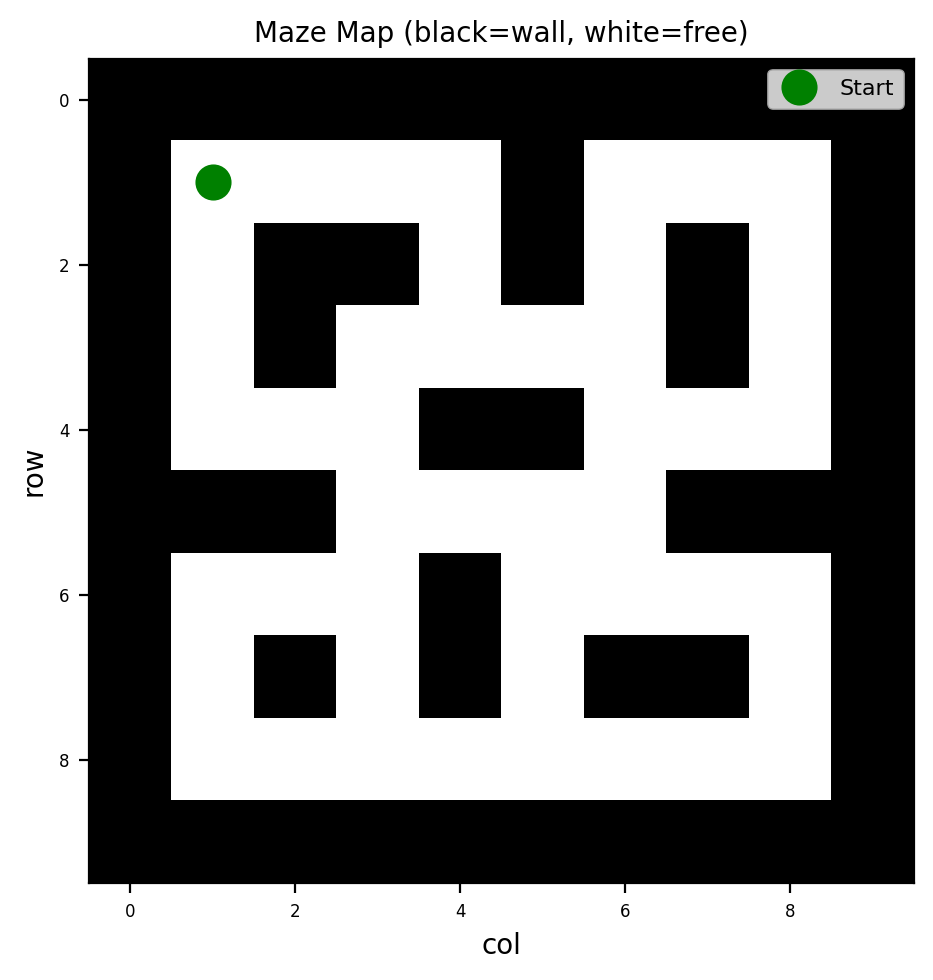

In [2]:
# Maze map (1=wall, 0=free)
MAZE_MAP = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 1],
    [1, 1, 1, 0, 0, 0, 0, 1, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

CELL_SIZE   = 2.6   # meters per cell
WALL_HEIGHT = 1.0   # wall height in meters
START_CELL  = (1, 1)  # (row, col) - robot start position
MAZE_MAP    = np.array(MAZE_MAP)
n_rows, n_cols = MAZE_MAP.shape

def cell_to_world(row, col):
    """Convert grid cell (row, col) to world coordinates (x, y)."""
    x = col * CELL_SIZE + CELL_SIZE / 2
    y = -(row * CELL_SIZE + CELL_SIZE / 2)
    return x, y

def generate_maze_xml(maze_map, cell_size, wall_height, xml_dir):
    """Generate MuJoCo scene XML with maze walls."""
    n_rows, n_cols = maze_map.shape
    wall_geoms = []
    wall_idx = 0
    for r in range(n_rows):
        for c in range(n_cols):
            if maze_map[r, c] == 1:
                x, y = cell_to_world(r, c)
                z = wall_height / 2
                sx = cell_size / 2
                sy = cell_size / 2
                sz = wall_height / 2
                wall_geoms.append(
                    f'    <geom name="wall_{wall_idx}" type="box" '
                    f'pos="{x:.3f} {y:.3f} {z:.3f}" '
                    f'size="{sx:.3f} {sy:.3f} {sz:.3f}" '
                    f'rgba="0.6 0.65 0.7 1" contype="1" conaffinity="1"/>'
                )
                wall_idx += 1
    walls_str = "\n".join(wall_geoms)
    
    xml = f"""<mujoco model="husky maze slam">
  <include file="./husky_w_lidar.xml"/>
  <include file="../object/floor_sky.xml"/>
  <worldbody>
    <!-- Maze walls ({wall_idx} total) -->
{walls_str}
    <!-- Base collision geom for Husky (invisible) -->
  </worldbody>
</mujoco>
"""
    xml_path = os.path.join(xml_dir, 'scene_husky_maze_slam.xml')
    with open(xml_path, 'w') as f:
        f.write(xml)
    return xml_path

# Generate the maze scene XML
asset_dir = os.path.abspath('../../asset/husky')
xml_path = generate_maze_xml(MAZE_MAP, CELL_SIZE, WALL_HEIGHT, asset_dir)
print(f"Generated maze scene XML: {xml_path}")
print(f"Maze size: {n_rows} x {n_cols} cells ({n_rows*CELL_SIZE:.0f}m x {n_cols*CELL_SIZE:.0f}m)")
print(f"Number of walls: {int(MAZE_MAP.sum())}")
print(f"Start cell: {START_CELL} -> world: {cell_to_world(*START_CELL)}")

# Visualize the maze map
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(MAZE_MAP, cmap='gray_r', origin='upper')
ax.plot(START_CELL[1], START_CELL[0], 'go', markersize=12, label='Start')
ax.set_title('Maze Map (black=wall, white=free)', fontsize=10)
ax.legend(fontsize=8)
ax.set_xlabel('col'); ax.set_ylabel('row')
plt.tight_layout()
plt.show()

### Load Scene and Initialize Viewer

In [3]:
xml_path = '../../asset/husky/scene_husky_maze_slam.xml'
env = MuJoCoParserClass(name='Husky_SLAM', rel_xml_path=xml_path, VERBOSE=True)
print("[%s] parsed." % (env.name))

# LiDAR config
N_LIDAR_RAYS = 72
LIDAR_ANGLE_STEP = 2 * np.pi / N_LIDAR_RAYS  # 5 degrees
LIDAR_MAX_RANGE = 10.0
lidar_angles_body = np.array([i * LIDAR_ANGLE_STEP for i in range(N_LIDAR_RAYS)])  # in body frame

# Set initial robot position
start_x, start_y = cell_to_world(*START_CELL)
env.data.qpos[0] = start_x
env.data.qpos[1] = start_y
env.data.qpos[2] = 0.1  # z height
mujoco.mj_forward(env.model, env.data)
print(f"Robot placed at ({start_x:.1f}, {start_y:.1f})")

dt:[0.0020] HZ:[500]
n_dof (=nv):[10]
n_geom:[65]
geom_names:['floor', 'wall_0', 'wall_1', 'wall_2', 'wall_3', 'wall_4', 'wall_5', 'wall_6', 'wall_7', 'wall_8', 'wall_9', 'wall_10', 'wall_11', 'wall_12', 'wall_13', 'wall_14', 'wall_15', 'wall_16', 'wall_17', 'wall_18', 'wall_19', 'wall_20', 'wall_21', 'wall_22', 'wall_23', 'wall_24', 'wall_25', 'wall_26', 'wall_27', 'wall_28', 'wall_29', 'wall_30', 'wall_31', 'wall_32', 'wall_33', 'wall_34', 'wall_35', 'wall_36', 'wall_37', 'wall_38', 'wall_39', 'wall_40', 'wall_41', 'wall_42', 'wall_43', 'wall_44', 'wall_45', 'wall_46', 'wall_47', 'wall_48', 'wall_49', 'wall_50', 'wall_51', 'wall_52', 'wall_53', None, None, None, None, None, None, None, None, None, None]
n_body:[6]
body_names:['world', 'base_husky', 'front_left_wheel_link', 'front_right_wheel_link', 'rear_left_wheel_link', 'rear_right_wheel_link']
n_joint:[5]
joint_names:['base_husky_joint', 'front_left_wheel', 'front_right_wheel', 'rear_left_wheel', 'rear_right_wheel']
joint_types:[0

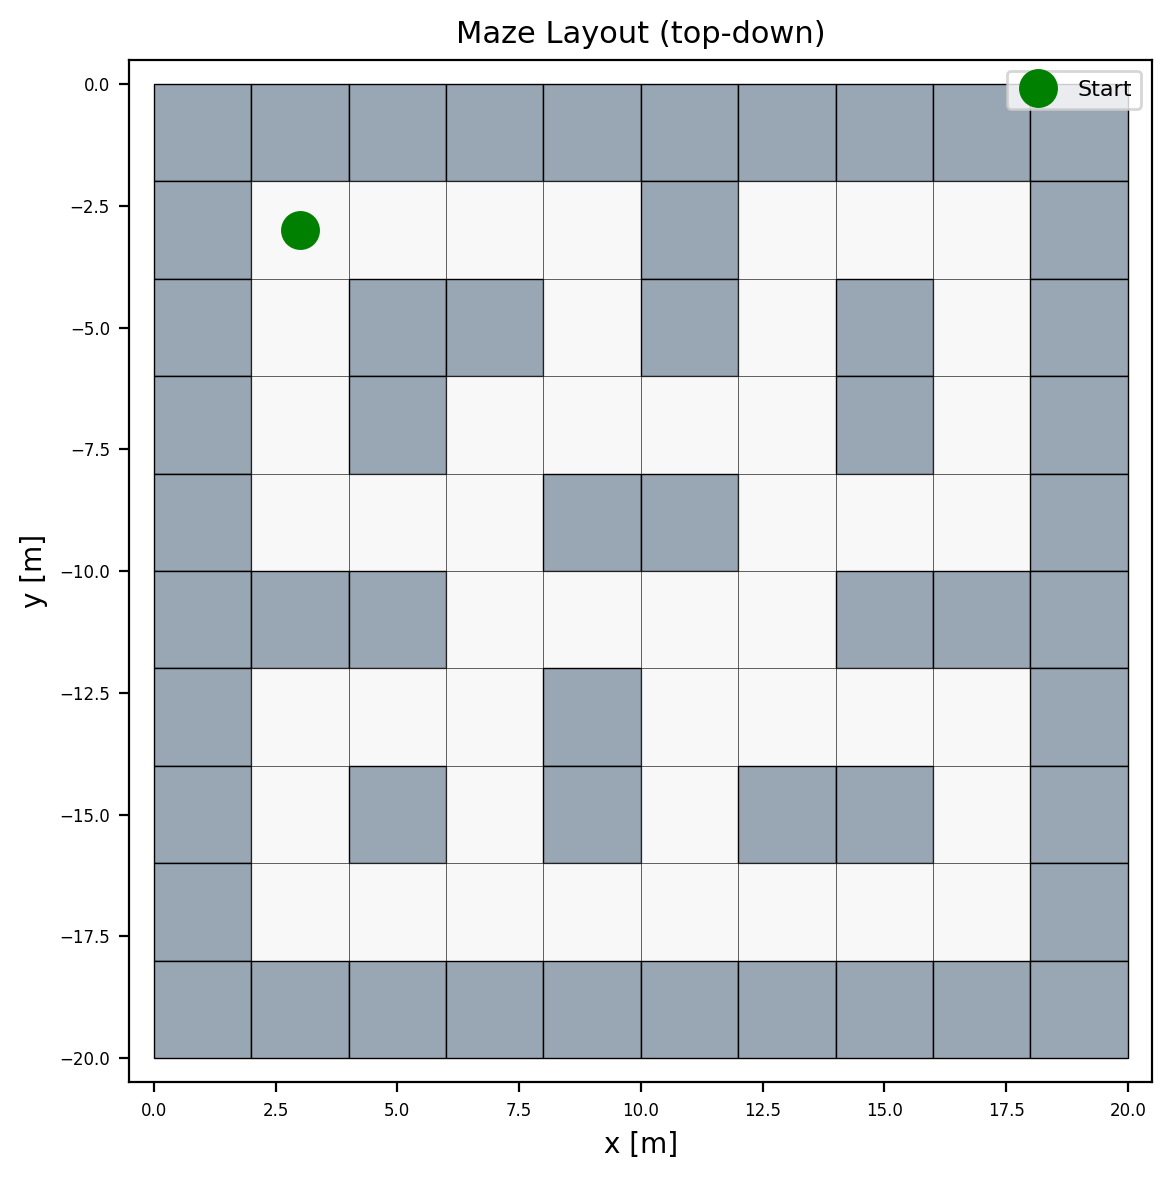

In [4]:
# Top-down maze visualization (no viewer needed)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
for r in range(n_rows):
    for c in range(n_cols):
        if MAZE_MAP[r, c] == 1:
            wx, wy = cell_to_world(r, c)
            rect = plt.Rectangle((wx - CELL_SIZE/2, wy - CELL_SIZE/2),
                CELL_SIZE, CELL_SIZE, fc=[0.6, 0.65, 0.7], ec='k', lw=0.5)
            ax.add_patch(rect)
        else:
            wx, wy = cell_to_world(r, c)
            rect = plt.Rectangle((wx - CELL_SIZE/2, wy - CELL_SIZE/2),
                CELL_SIZE, CELL_SIZE, fc=[0.95, 0.95, 0.95], ec='k', lw=0.3, alpha=0.5)
            ax.add_patch(rect)
ax.plot(start_x, start_y, 'go', ms=12, mew=2, label='Start')
ax.set_xlim(-0.5, n_cols * CELL_SIZE + 0.5)
ax.set_ylim(-(n_rows * CELL_SIZE + 0.5), 0.5)
ax.set_aspect('equal')
ax.set_title('Maze Layout (top-down)', fontsize=11)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2D LiDAR Sensing

Read the 72 rangefinder sensors to get a 360-degree distance scan. Each ray returns the distance to the nearest obstacle along its direction.

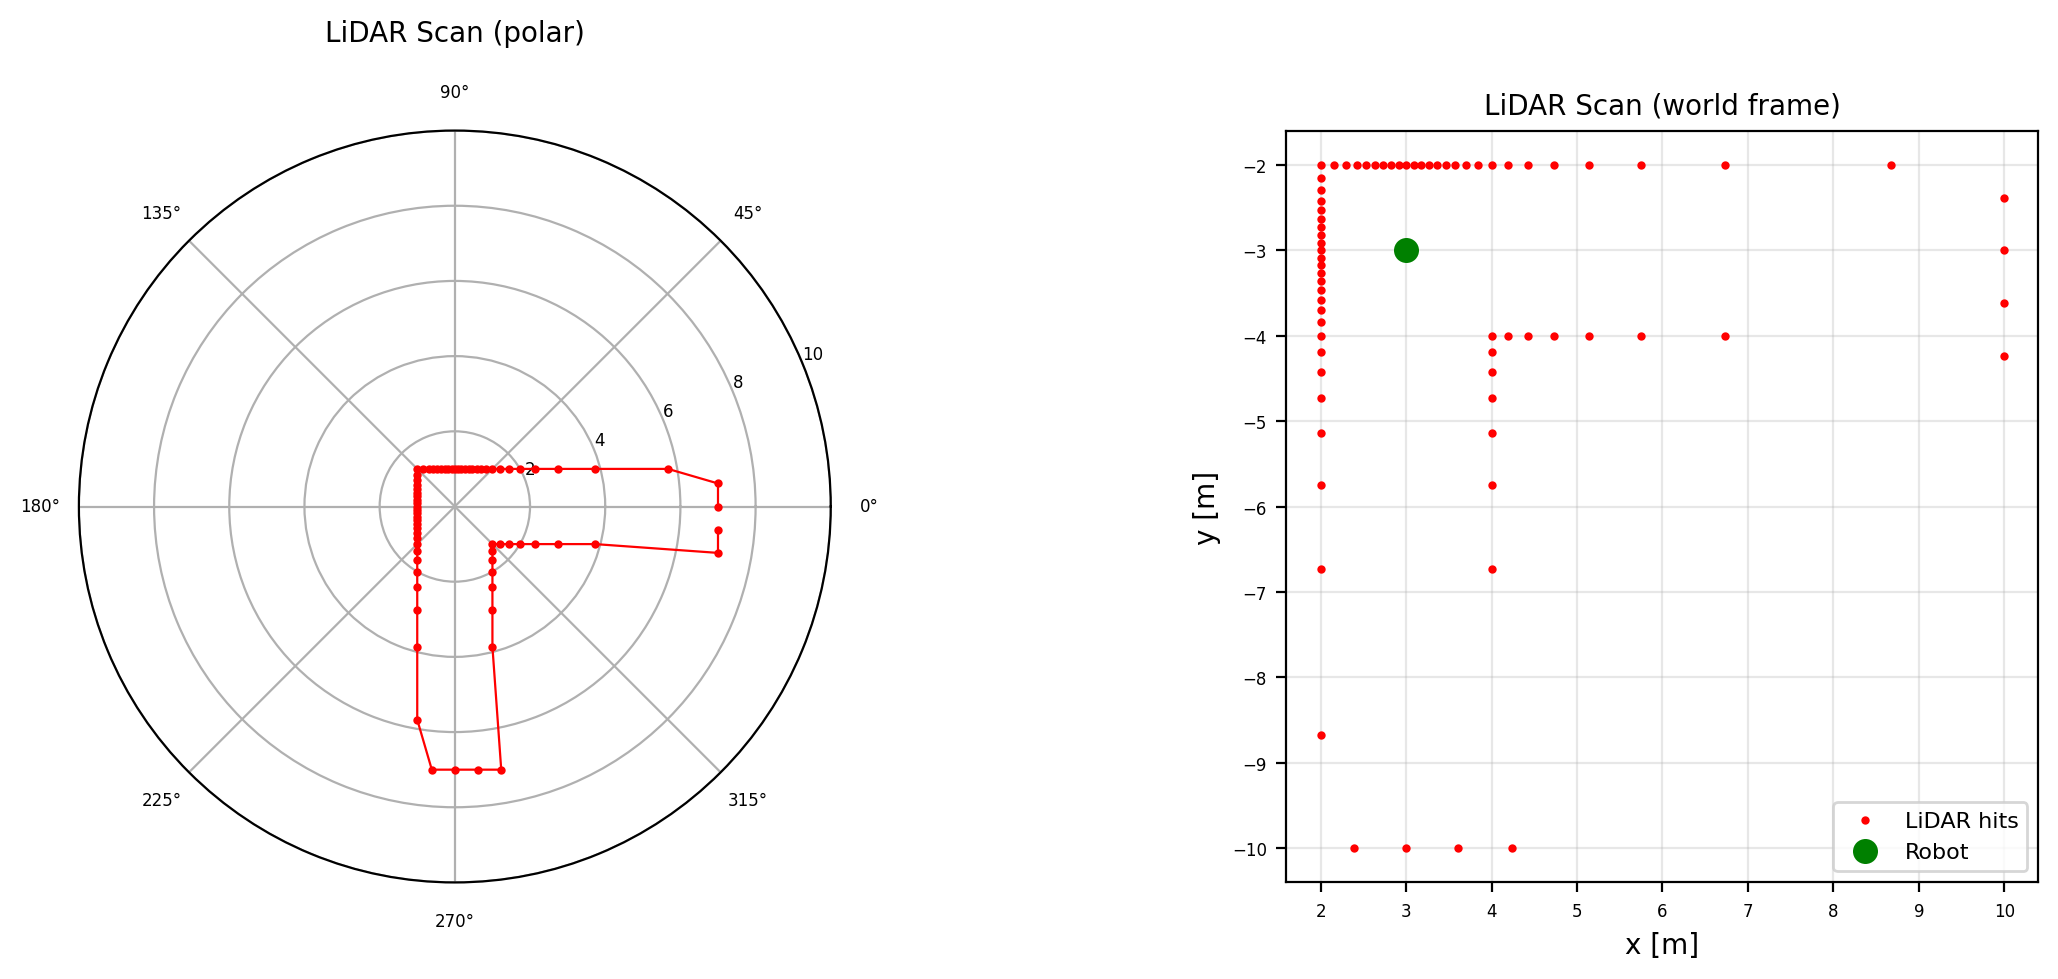

Min range: 1.00m, Max range: 7.11m
Rays hitting obstacles: 72/72


In [5]:
def get_lidar_scan(env, n_rays=72, max_range=10.0):
    """Read all rangefinder sensors and return distances.
    Returns -1 for rays that don't hit anything (treated as max_range).
    """
    ranges = np.zeros(n_rays)
    for i in range(n_rays):
        val = env.get_sensor_value(f'lidar_{i:03d}')[0]
        ranges[i] = val if val >= 0 else max_range
    return ranges

def lidar_to_world_points(ranges, robot_x, robot_y, robot_yaw, n_rays=72):
    """Convert lidar ranges to world-frame (x, y) hit points."""
    angles_body = np.linspace(0, 2*np.pi, n_rays, endpoint=False)
    angles_world = angles_body + robot_yaw
    hit_x = robot_x + ranges * np.cos(angles_world)
    hit_y = robot_y + ranges * np.sin(angles_world)
    return hit_x, hit_y, angles_world

# Take a single scan at the start position
mujoco.mj_forward(env.model, env.data)
ranges = get_lidar_scan(env, N_LIDAR_RAYS, LIDAR_MAX_RANGE)

# Plot polar scan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
angles_deg = np.linspace(0, 360, N_LIDAR_RAYS, endpoint=False)
angles_rad = np.deg2rad(angles_deg)

# Polar plot
ax = fig.add_subplot(121, projection='polar')
axes[0].set_visible(False)
ax.plot(angles_rad, ranges, 'r.-', markersize=4, linewidth=0.8)
ax.set_rmax(LIDAR_MAX_RANGE)
ax.set_title('LiDAR Scan (polar)', fontsize=10, pad=15)
ax.set_theta_zero_location('E')

# Cartesian plot
ax2 = axes[1]
p_robot = env.get_p_body('base_husky')
R_robot = env.get_R_body('base_husky')
yaw = r2rpy(R_robot)[2]
hit_x, hit_y, _ = lidar_to_world_points(ranges, p_robot[0], p_robot[1], yaw, N_LIDAR_RAYS)
# Filter out max-range points for cleaner visualization
mask = ranges < LIDAR_MAX_RANGE - 0.1
ax2.plot(hit_x[mask], hit_y[mask], 'r.', markersize=4, label='LiDAR hits')
ax2.plot(p_robot[0], p_robot[1], 'go', markersize=8, label='Robot')
ax2.set_aspect('equal')
ax2.set_title('LiDAR Scan (world frame)', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x [m]'); ax2.set_ylabel('y [m]')
plt.tight_layout()
plt.show()

print(f"Min range: {ranges.min():.2f}m, Max range: {ranges.max():.2f}m")
print(f"Rays hitting obstacles: {np.sum(ranges < LIDAR_MAX_RANGE - 0.1)}/{N_LIDAR_RAYS}")
def render_lidar(env, p_robot, yaw_gt, ranges, n_rays=72, max_range=10.0):
    """Render LiDAR: scan outline connecting adjacent hit points."""
    hit_x, hit_y, _ = lidar_to_world_points(ranges, p_robot[0], p_robot[1], yaw_gt, n_rays)
    mask = ranges < max_range - 0.1
    z = 0.65
    hit_indices = np.where(mask)[0]
    # Scan outline only: connect adjacent hit points
    for k in range(len(hit_indices)):
        i0, i1 = hit_indices[k], hit_indices[(k+1) % len(hit_indices)]
        if abs(i1 - i0) <= 2 or abs(i1 - i0) >= n_rays - 2:
            p0 = np.array([hit_x[i0], hit_y[i0], z])
            p1 = np.array([hit_x[i1], hit_y[i1], z])
            env.plot_line_fr2to(p_fr=p0, p_to=p1, rgba=[1.0, 0.2, 0.1, 0.08])
    # Small hit point spheres
    for i in hit_indices:
        env.plot_sphere(p=np.array([hit_x[i], hit_y[i], z]),
                        r=0.025, rgba=[1.0, 0.3, 0.1, 0.12])



### Occupancy Grid Mapping

Implement a 2D occupancy grid map using log-odds representation:
- Each cell stores a log-odds value indicating obstacle probability
- **Bresenham ray casting**: trace each LiDAR ray through the grid, marking traversed cells as *free* and the endpoint as *occupied*
- Log-odds update: `L(cell) += l_occ` for hits, `L(cell) += l_free` for free cells

In [6]:
class OccupancyGrid:
    def __init__(self, x_range, y_range, resolution=0.1):
        """
        Initialize occupancy grid.
        Args:
            x_range: (x_min, x_max) in meters
            y_range: (y_min, y_max) in meters
            resolution: grid cell size in meters
        """
        self.resolution = resolution
        self.x_min, self.x_max = x_range
        self.y_min, self.y_max = y_range
        self.width  = int(np.ceil((self.x_max - self.x_min) / resolution))
        self.height = int(np.ceil((self.y_max - self.y_min) / resolution))
        # Log-odds grid (0 = unknown)
        self.log_odds = np.zeros((self.height, self.width), dtype=np.float32)
        # Update parameters
        self.l_occ  =  0.7   # log-odds increment for occupied
        self.l_free = -0.4   # log-odds increment for free
        self.l_max  =  5.0   # clamp max
        self.l_min  = -5.0   # clamp min
        print(f"OccupancyGrid: {self.width}x{self.height} cells, "
              f"resolution={resolution}m, "
              f"world=[{self.x_min:.1f},{self.x_max:.1f}]x[{self.y_min:.1f},{self.y_max:.1f}]")

    def world_to_grid(self, x, y):
        """Convert world coordinates to grid indices."""
        gx = int((x - self.x_min) / self.resolution)
        gy = int((y - self.y_min) / self.resolution)
        gx = np.clip(gx, 0, self.width - 1)
        gy = np.clip(gy, 0, self.height - 1)
        return gx, gy

    def bresenham(self, x0, y0, x1, y1):
        """Bresenham's line algorithm. Returns list of (x, y) grid cells."""
        cells = []
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy
        while True:
            cells.append((x0, y0))
            if x0 == x1 and y0 == y1:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x0 += sx
            if e2 < dx:
                err += dx
                y0 += sy
        return cells

    def update(self, robot_x, robot_y, robot_yaw, ranges, n_rays=72, max_range=10.0):
        """Update the occupancy grid with a LiDAR scan."""
        rx, ry = self.world_to_grid(robot_x, robot_y)
        angles_body = np.linspace(0, 2*np.pi, n_rays, endpoint=False)
        
        for i in range(n_rays):
            angle_world = angles_body[i] + robot_yaw
            r = ranges[i]
            is_hit = r < max_range - 0.1
            
            # Endpoint in world frame
            end_x = robot_x + r * np.cos(angle_world)
            end_y = robot_y + r * np.sin(angle_world)
            ex, ey = self.world_to_grid(end_x, end_y)
            
            # Trace ray with Bresenham
            cells = self.bresenham(rx, ry, ex, ey)
            
            # Mark free cells (all except last)
            for (cx, cy) in cells[:-1]:
                if 0 <= cx < self.width and 0 <= cy < self.height:
                    self.log_odds[cy, cx] += self.l_free
            
            # Mark endpoint as occupied (if hit)
            if is_hit and 0 <= ex < self.width and 0 <= ey < self.height:
                self.log_odds[ey, ex] += self.l_occ
        
        # Clamp
        np.clip(self.log_odds, self.l_min, self.l_max, out=self.log_odds)

    def get_map_image(self):
        """Convert log-odds to probability map for visualization.
        Returns image: 0=free (white), 0.5=unknown (gray), 1=occupied (black).
        """
        prob = 1.0 - 1.0 / (1.0 + np.exp(self.log_odds))
        return prob

# Create occupancy grid covering the maze area (with some margin)
margin = 2.0
og = OccupancyGrid(
    x_range=(-margin, n_cols * CELL_SIZE + margin),
    y_range=(-(n_rows * CELL_SIZE + margin), margin),
    resolution=0.1
)

OccupancyGrid: 240x240 cells, resolution=0.1m, world=[-2.0,22.0]x[-22.0,2.0]


### Wall-Following Navigation + Occupancy Grid SLAM

The robot autonomously explores the maze using a **right-hand wall-following** strategy:
1. Keep a wall on the right side
2. Turn left when blocked ahead
3. Turn right when the right wall disappears

Simultaneously, the occupancy grid map is built from LiDAR scans.

In [7]:
# Differential drive parameters
wheel_radius = 0.17775 / 2.0
wheel_base = 0.2854 * 2

# Wall-following parameters
SAFE_FRONT_DIST  = 1.2   # minimum distance ahead before turning
DESIRED_WALL_DIST = 0.8  # desired distance to right wall
WALL_DIST_TOL    = 0.3   # tolerance band
FORWARD_SPEED    = 1.5   # m/s
TURN_SPEED       = 2.0   # rad/s

# Exploration parameters
SIM_DURATION     = 120.0  # seconds of exploration
LIDAR_HZ         = 5     # LiDAR scan frequency
RENDER_HZ        = 30    # rendering frequency

# Storage for trajectory
gt_trajectory = []    # ground truth (from simulation)
odom_trajectory = []  # dead reckoning (from wheel odometry)

# Odometry state
odom_x, odom_y, odom_yaw = cell_to_world(*START_CELL)[0], cell_to_world(*START_CELL)[1], 0.0

def wall_following_controller(ranges, n_rays=72):
    """Right-hand wall-following reactive controller.
    Ray 0 = forward (+x body), Ray 18 = left (+y body), 
    Ray 36 = backward (-x body), Ray 54 = right (-y body).
    """
    # Extract sector distances (min over angular sectors)
    front_idxs = list(range(0, 7)) + list(range(65, 72))
    right_idxs = list(range(49, 61))
    left_idxs  = list(range(11, 25))
    
    front_dist = np.min(ranges[front_idxs])
    right_dist = np.min(ranges[right_idxs])
    left_dist  = np.min(ranges[left_idxs])
    
    if front_dist < SAFE_FRONT_DIST:
        # Obstacle ahead -> turn left
        v = 0.2
        w = TURN_SPEED
    elif right_dist > DESIRED_WALL_DIST + WALL_DIST_TOL:
        # Lost right wall -> turn right to find it
        v = FORWARD_SPEED * 0.7
        w = -TURN_SPEED * 0.6
    elif right_dist < DESIRED_WALL_DIST - WALL_DIST_TOL:
        # Too close to right wall -> steer left slightly
        v = FORWARD_SPEED * 0.8
        w = TURN_SPEED * 0.4
    else:
        # Wall at good distance -> go forward
        v = FORWARD_SPEED
        w = 0.0
    return v, w

# Initialize viewer
env.init_viewer(viewer_title='Husky SLAM', viewer_width=1200, viewer_height=800,
                viewer_hide_menus=True)
env.update_viewer(azimuth=90, distance=25, elevation=-75,
                  lookat=[n_cols*CELL_SIZE/2, -n_rows*CELL_SIZE/2, 0.0])

# Change controller gain
    kv = 1.0

# Set initial position
env.reset()
env.data.qpos[0] = start_x
env.data.qpos[1] = start_y
env.data.qpos[2] = 0.1
mujoco.mj_forward(env.model, env.data)

scan_count = 0
frames = []
v, w = 0.0, 0.0  # initial velocity commands
ranges = get_lidar_scan(env, N_LIDAR_RAYS, LIDAR_MAX_RANGE)  # initial scan

while (env.get_sim_time() < SIM_DURATION) and env.is_viewer_alive():
    # Get robot state (ground truth)
    p_robot = env.get_p_body('base_husky')
    R_robot = env.get_R_body('base_husky')
    yaw_gt = r2rpy(R_robot)[2]
    
    # LiDAR scan + mapping at LIDAR_HZ
    if env.loop_every(HZ=LIDAR_HZ) or (env.tick == 1):
        ranges = get_lidar_scan(env, N_LIDAR_RAYS, LIDAR_MAX_RANGE)
        
        # Update occupancy grid (using ground truth pose)
        og.update(p_robot[0], p_robot[1], yaw_gt, ranges, N_LIDAR_RAYS, LIDAR_MAX_RANGE)
        scan_count += 1
        
        # Wall-following control
        v, w = wall_following_controller(ranges, N_LIDAR_RAYS)
        
        # Store ground truth trajectory
        gt_trajectory.append([p_robot[0], p_robot[1], yaw_gt])
    
    # Differential drive: convert (v, w) to wheel velocities
    # Differential drive: (v, w) -> wheel linear velocities (matching demo_02 convention)
    vl = v - (w * wheel_base / 2)
    vr = v + (w * wheel_base / 2)
    vel_targets = np.array([vl, vr, vl, vr], dtype=np.float32) / wheel_radius
    np.clip(vel_targets, -50, 50, out=vel_targets)
    env.step(ctrl=vel_targets, ctrl_idxs=[0, 1, 2, 3])
    
    # Odometry update (dead reckoning from commanded velocities)
    dt = env.dt
    odom_x   += v * np.cos(odom_yaw) * dt
    odom_y   += v * np.sin(odom_yaw) * dt
    odom_yaw += w * dt
    
    # Render
    if env.loop_every(HZ=RENDER_HZ) or (env.tick == 1):
        render_lidar(env, p_robot, yaw_gt, ranges, N_LIDAR_RAYS, LIDAR_MAX_RANGE)
        
        env.plot_body_T(body_name='base_husky', PLOT_AXIS=True,
                       axis_len=0.3, axis_width=0.02)
        env.plot_T(p=p_robot + np.array([0, 0, 1.0]), R=np.eye(3),
                   PLOT_AXIS=False,
                   label='t=%.1fs scans=%d' % (env.get_sim_time(), scan_count))
        env.render()
    
    # Capture frames for visualization
    if env.loop_every(HZ=2):
        frames.append(env.grab_image(resize_rate=0.5))

env.close_viewer()
gt_trajectory = np.array(gt_trajectory)
print(f"Exploration done. Time: {env.get_sim_time():.1f}s, Scans: {scan_count}, "
      f"Trajectory points: {len(gt_trajectory)}")

Pressed ESC
Quitting.
Exploration done. Time: 5.6s, Scans: 29, Trajectory points: 29


2026-06-14 20:24:04.788 python[27790:75716833] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


### Visualization: Occupancy Grid Map + Trajectory

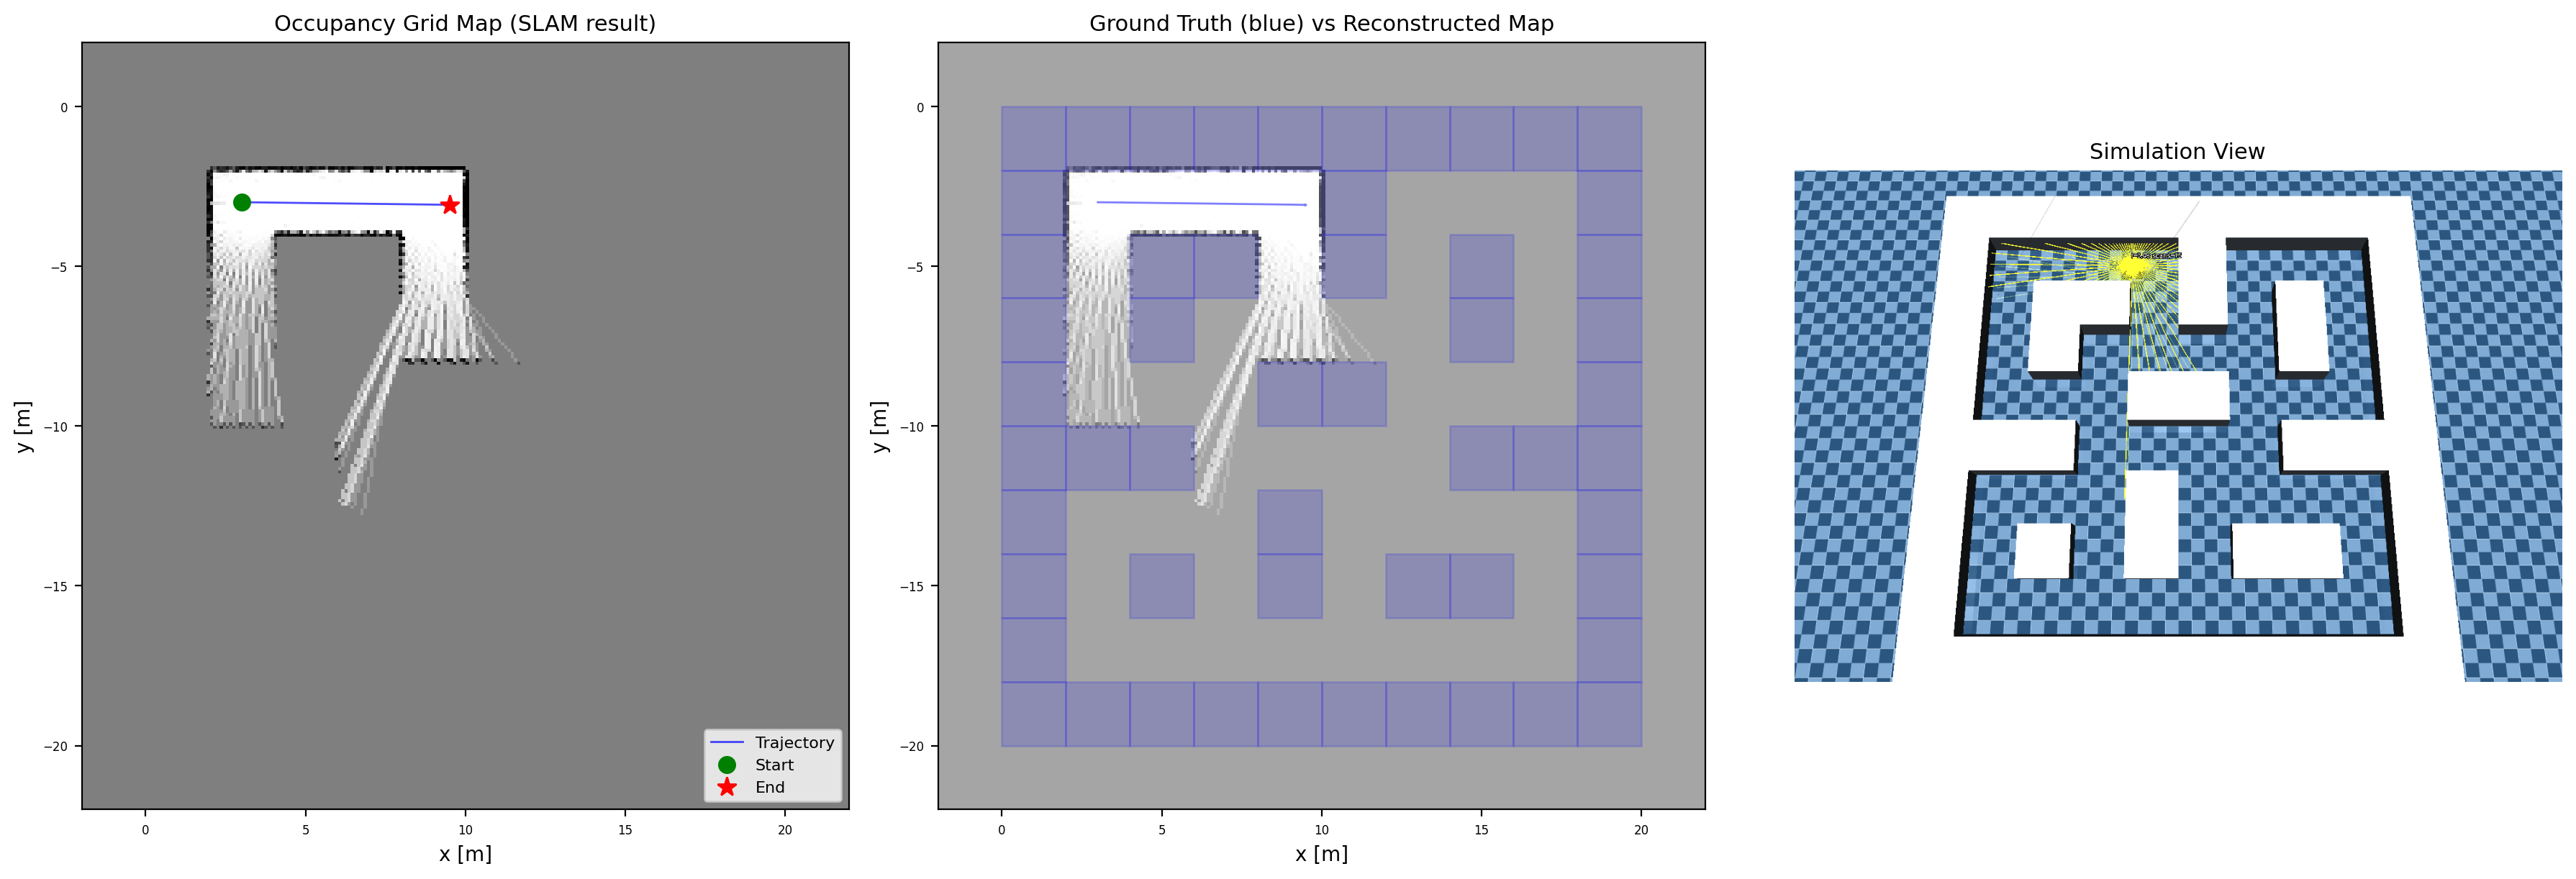


Mapping Statistics:
  Grid size: 240 x 240 = 57600 cells
  Mapped free: 2888 cells
  Mapped occupied: 290 cells
  Mapped total: 3178 / 57600 (5.5%)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Occupancy grid map
ax = axes[0]
map_img = og.get_map_image()
ax.imshow(map_img, cmap='gray_r', origin='lower',
          extent=[og.x_min, og.x_max, og.y_min, og.y_max])
if len(gt_trajectory) > 0:
    ax.plot(gt_trajectory[:, 0], gt_trajectory[:, 1], 'b-', linewidth=1.0, alpha=0.7, label='Trajectory')
    ax.plot(gt_trajectory[0, 0], gt_trajectory[0, 1], 'go', markersize=8, label='Start')
    ax.plot(gt_trajectory[-1, 0], gt_trajectory[-1, 1], 'r*', markersize=10, label='End')
ax.set_title('Occupancy Grid Map (SLAM result)', fontsize=11)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='lower right')

# 2. Ground truth maze vs reconstructed map overlay
ax2 = axes[1]
# Draw ground truth walls
for r in range(n_rows):
    for c in range(n_cols):
        if MAZE_MAP[r, c] == 1:
            wx, wy = cell_to_world(r, c)
            rect = plt.Rectangle(
                (wx - CELL_SIZE/2, wy - CELL_SIZE/2),
                CELL_SIZE, CELL_SIZE,
                linewidth=1, edgecolor='blue', facecolor='blue', alpha=0.15)
            ax2.add_patch(rect)
# Overlay reconstructed map
ax2.imshow(map_img, cmap='gray_r', origin='lower', alpha=0.7,
           extent=[og.x_min, og.x_max, og.y_min, og.y_max])
if len(gt_trajectory) > 0:
    ax2.plot(gt_trajectory[:, 0], gt_trajectory[:, 1], 'b-', linewidth=1.0, alpha=0.5)
ax2.set_title('Ground Truth (blue) vs Reconstructed Map', fontsize=11)
ax2.set_xlabel('x [m]'); ax2.set_ylabel('y [m]')
ax2.set_aspect('equal')

# 3. Captured frame from simulation
ax3 = axes[2]
if len(frames) > 0:
    ax3.imshow(frames[len(frames)//2])
ax3.set_title('Simulation View', fontsize=11)
ax3.axis('off')

plt.tight_layout()
plt.show()

# Coverage statistics
total_free_cells = np.sum(MAZE_MAP == 0)
mapped_free = np.sum(map_img < 0.3)  # cells detected as free
mapped_occ  = np.sum(map_img > 0.7)  # cells detected as occupied
total_mapped = mapped_free + mapped_occ
total_grid_cells = og.width * og.height
print(f"\nMapping Statistics:")
print(f"  Grid size: {og.width} x {og.height} = {total_grid_cells} cells")
print(f"  Mapped free: {mapped_free} cells")
print(f"  Mapped occupied: {mapped_occ} cells")
print(f"  Mapped total: {total_mapped} / {total_grid_cells} ({100*total_mapped/total_grid_cells:.1f}%)")

### LiDAR Scan Snapshots During Exploration

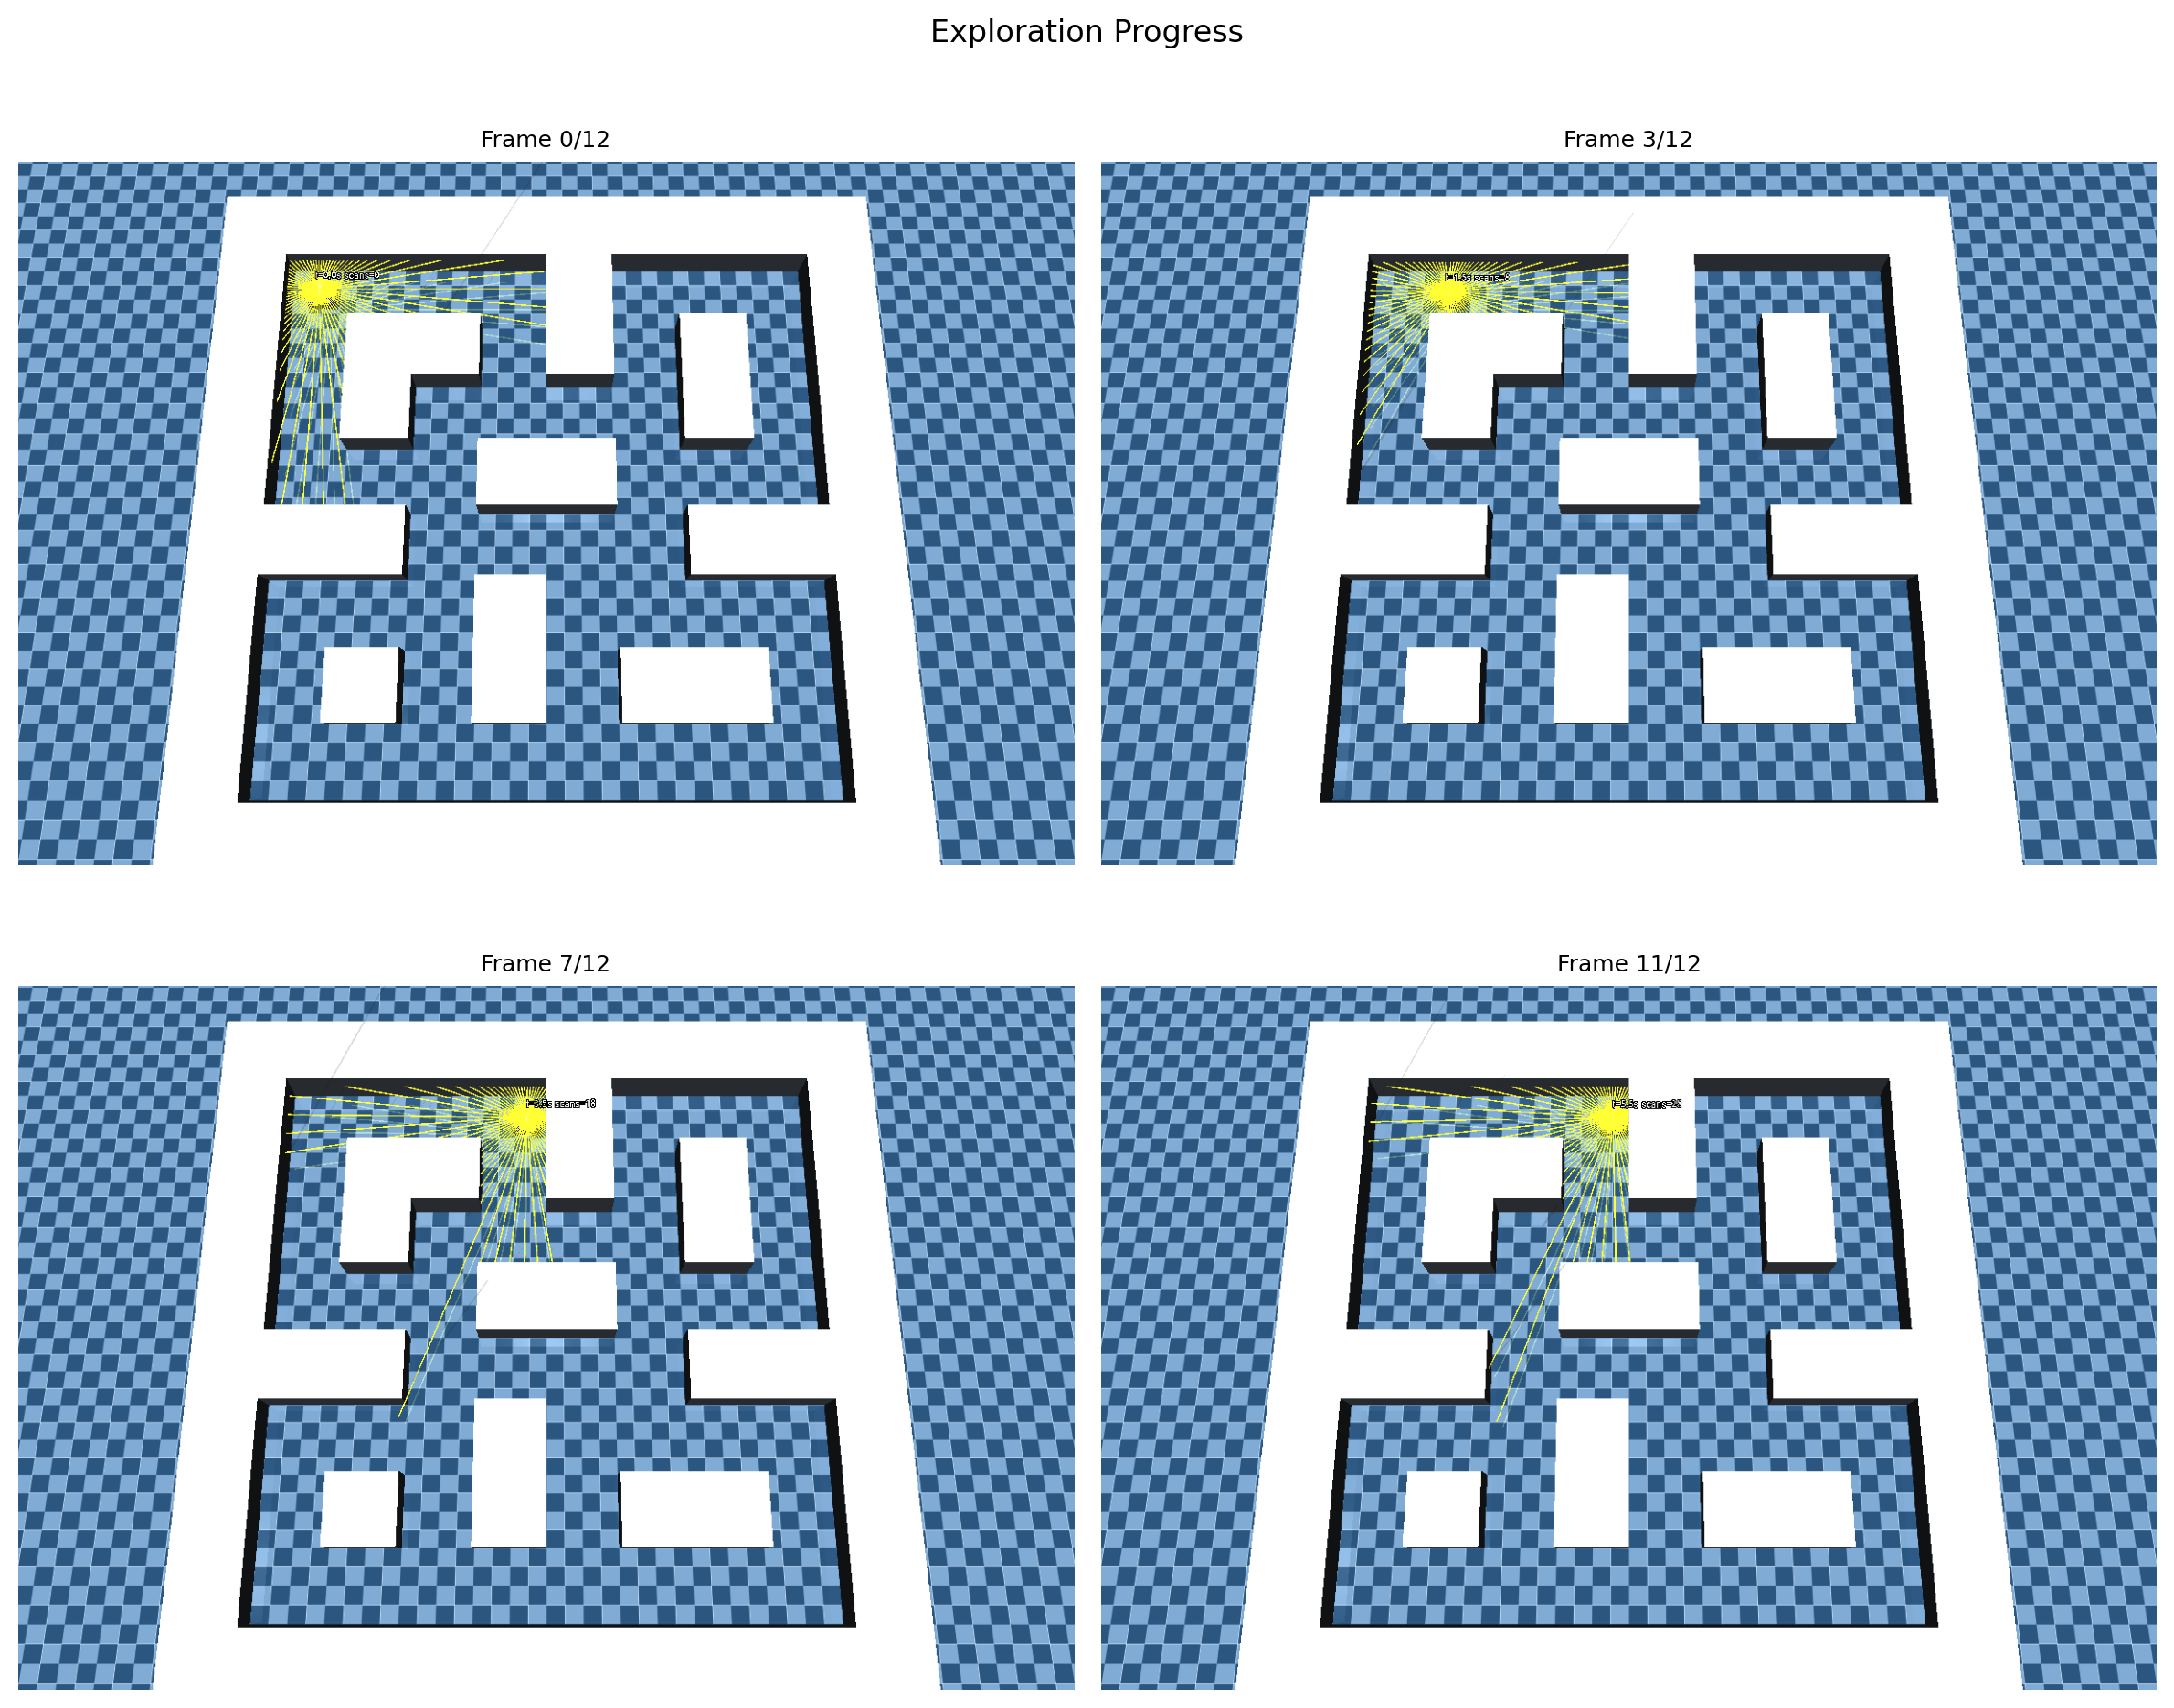

In [9]:
if len(frames) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    idxs = np.linspace(0, len(frames)-1, 4, dtype=int)
    for ax, idx in zip(axes.flat, idxs):
        ax.imshow(frames[idx])
        ax.set_title(f'Frame {idx}/{len(frames)}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Exploration Progress', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough frames captured. Run the SLAM loop for longer.")

### Try a Custom Maze

You can modify `MAZE_MAP` above and re-run the cells. For example:

```python
# Simple U-maze
MAZE_MAP = np.array([
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1],
])

# Large maze
MAZE_MAP = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
    [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1],
    [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
])
```